In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/FundamentofDS/processed/binary/ptbxl_labeled (binary).csv')

In [4]:
df.head(5)

,ecg_id,patient_id,age,sex,height,weight,strat_fold,filename_lr,filename_hr,scp_codes,superclasses,NORM,MI,STTC,CD,HYP,is_anomaly,binary_label
0,1,15709.0,56.0,1,NaN,63.0,3,records100/00000/00001_lr,records500/00000/00001_hr,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",['NORM'],1,0,0,0,0,0,Normal
1,2,13243.0,19.0,0,NaN,70.0,2,records100/00000/00002_lr,records500/00000/00002_hr,"{'NORM': 80.0, 'SBRAD': 0.0}",['NORM'],1,0,0,0,0,0,Normal
2,3,20372.0,37.0,1,NaN,69.0,5,records100/00000/00003_lr,records500/00000/00003_hr,"{'NORM': 100.0, 'SR': 0.0}",['NORM'],1,0,0,0,0,0,Normal
3,4,17014.0,24.0,0,NaN,82.0,3,records100/00000/00004_lr,records500/00000/00004_hr,"{'NORM': 100.0, 'SR': 0.0}",['NORM'],1,0,0,0,0,0,Normal
4,5,17448.0,19.0,1,NaN,70.0,4,records100/00000/00005_lr,records500/00000/00005_hr,"{'NORM': 100.0, 'SR': 0.0}",['NORM'],1,0,0,0,0,0,Normal


In [ ]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.6 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import wfdb
from scipy import signal
record_path = df.iloc[0]['filename_lr']
rec_dir = os.path.dirname(record_path)
rec_name = os.path.basename(record_path)
raw_signal, _ = wfdb.rdsamp(rec_name, pn_dir=f"ptb-xl/1.0.3/{rec_dir}")

fs = 100
lead_idx = 1
time_axis = np.linspace(0, len(raw_signal) / fs, len(raw_signal))

def remove_spikes(sig, threshold_factor=4.5):
    cleaned_sig = sig.copy()
    med = np.median(sig, axis=0)
    mad = np.median(np.abs(sig - med), axis=0)

    threshold = threshold_factor * (mad + 1e-6)
    is_spike = np.abs(sig - med) > threshold

    med_filtered = signal.medfilt(sig, kernel_size=(5, 1))
    cleaned_sig[is_spike] = med_filtered[is_spike]
    return cleaned_sig

despiked_signal = remove_spikes(raw_signal, threshold_factor=4.5)

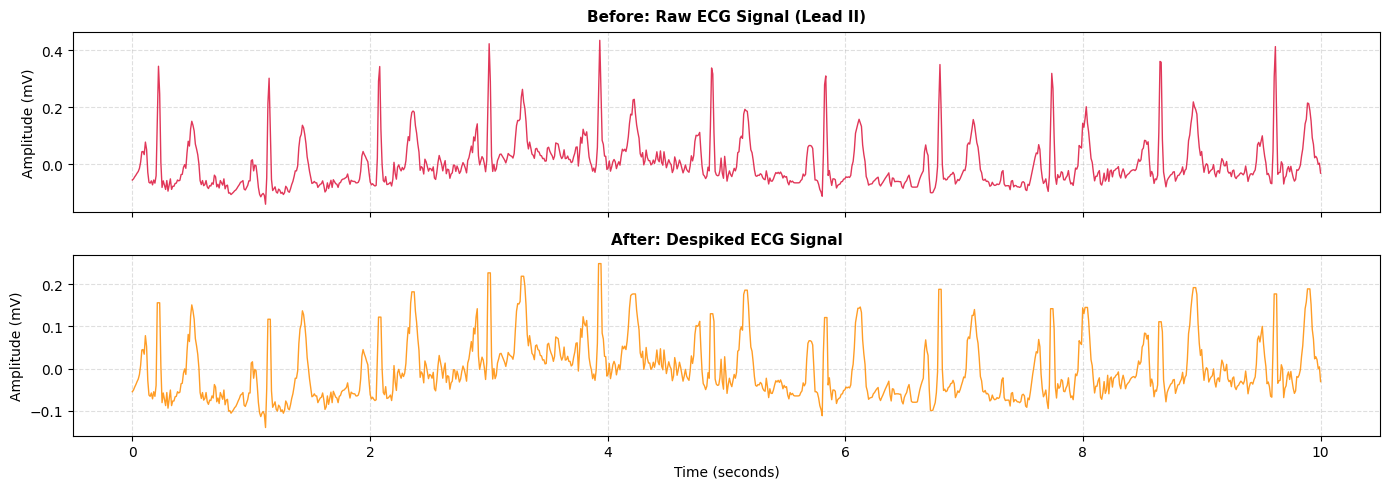

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(time_axis, raw_signal[:, lead_idx], color='crimson', alpha=0.85, lw=1)
axes[0].set_title('Before: Raw ECG Signal (Lead II)', fontsize=11, fontweight='bold', pad=8)
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(time_axis, despiked_signal[:, lead_idx], color='darkorange', alpha=0.85, lw=1)
axes[1].set_title('After: Despiked ECG Signal', fontsize=11, fontweight='bold', pad=8)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
lowcut, highcut = 0.5, 40.0
nyq = 0.5 * fs
b, a = signal.butter(2, [lowcut/nyq, highcut/nyq], btype='band')
filtered_signal = signal.filtfilt(b, a, despiked_signal, axis=0)

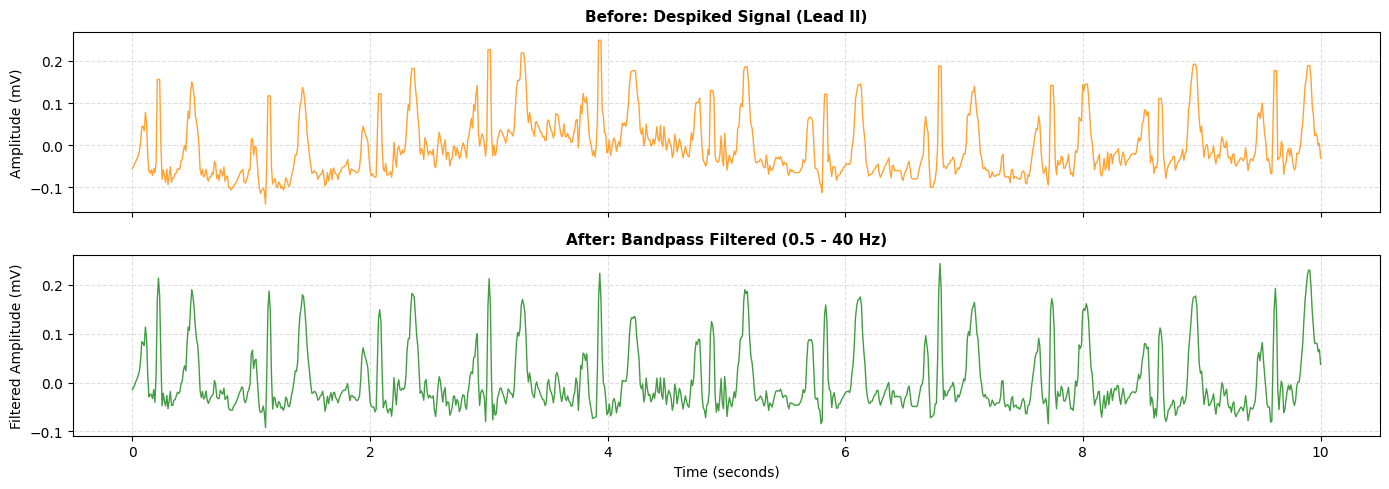

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(time_axis, despiked_signal[:, lead_idx], color='darkorange', alpha=0.8, lw=1)
axes[0].set_title('Before: Despiked Signal (Lead II)', fontsize=11, fontweight='bold', pad=8)
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(time_axis, filtered_signal[:, lead_idx], color='forestgreen', alpha=0.85, lw=1)
axes[1].set_title('After: Bandpass Filtered (0.5 - 40 Hz)', fontsize=11, fontweight='bold', pad=8)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Filtered Amplitude (mV)')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
final_signal = scaler.fit_transform(filtered_signal)

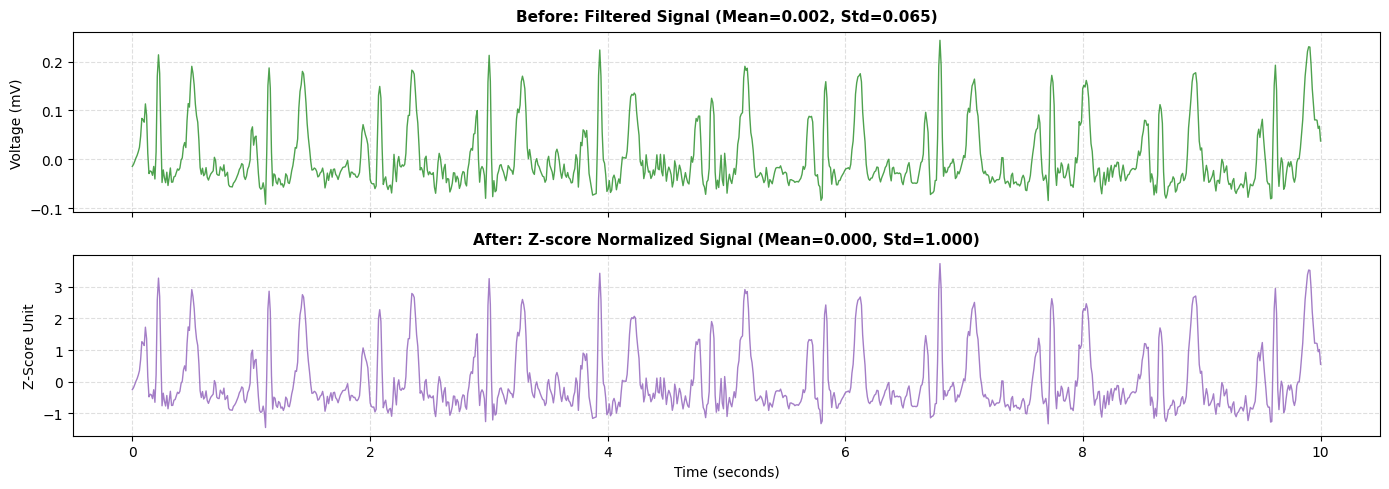

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(time_axis, filtered_signal[:, lead_idx], color='forestgreen', alpha=0.8, lw=1)
axes[0].set_title(f'Before: Filtered Signal (Mean={np.mean(filtered_signal[:, lead_idx]):.3f}, Std={np.std(filtered_signal[:, lead_idx]):.3f})', fontsize=11, fontweight='bold', pad=8)
axes[0].set_ylabel('Voltage (mV)')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(time_axis, final_signal[:, lead_idx], color='tab:purple', alpha=0.85, lw=1)
axes[1].set_title(f'After: Z-score Normalized Signal (Mean={np.mean(final_signal[:, lead_idx]):.3f}, Std={np.std(final_signal[:, lead_idx]):.3f})', fontsize=11, fontweight='bold', pad=8)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Z-Score Unit')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
spike_diff = np.max(np.abs(raw_signal - despiked_signal))
num_spikes_detected = np.sum(np.abs(raw_signal - np.median(raw_signal, axis=0)) > 4.5 * (np.median(np.abs(raw_signal - np.median(raw_signal, axis=0)), axis=0) + 1e-6))
print(f"[1] Number of detected spikes: {num_spikes_detected}")
print(f"    Max amplitude difference after despiking: {spike_diff:.6f} mV")

filter_diff = np.mean(np.abs(despiked_signal - filtered_signal))
print(f"[2] Mean difference after Bandpass Filter: {filter_diff:.6f} mV")

print(f"[3] Z-score Verification:")
print(f"    Raw  -> Mean: {np.mean(filtered_signal):.4f}, Std: {np.std(filtered_signal):.4f}")
print(f"    Norm -> Mean: {np.mean(final_signal):.4f}, Std: {np.std(final_signal):.4f}")

[1] Number of detected spikes: 868
    Max amplitude difference after despiking: 0.823000 mV
[2] Mean difference after Bandpass Filter: 0.026084 mV
[3] Z-score Verification:
    Raw  -> Mean: 0.0005, Std: 0.0740
    Norm -> Mean: 0.0000, Std: 1.0000


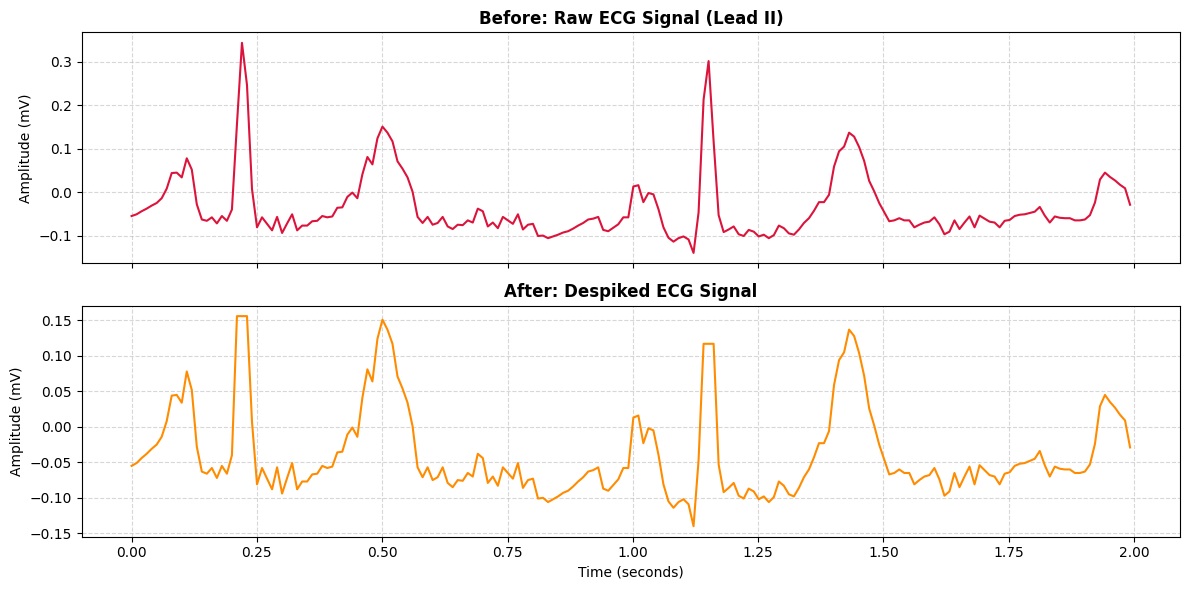

In [ ]:
zoom_sec = 2
zoom_samples = int(zoom_sec * fs)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(time_axis[:zoom_samples], raw_signal[:zoom_samples, lead_idx], color='crimson', lw=1.5)
axes[0].set_title('Before: Raw ECG Signal (Lead II)', fontweight='bold')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(time_axis[:zoom_samples], despiked_signal[:zoom_samples, lead_idx], color='darkorange', lw=1.5)
axes[1].set_title('After: Despiked ECG Signal', fontweight='bold')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
from tqdm import tqdm
def preprocess_ecg_signal(raw_signal, fs=100):
    despiked = remove_spikes(raw_signal, threshold_factor=4.5)

    lowcut, highcut = 0.5, 40.0
    nyq = 0.5 * fs
    b, a = signal.butter(2, [lowcut/nyq, highcut/nyq], btype='band')
    filtered = signal.filtfilt(b, a, despiked, axis=0)

    scaler = StandardScaler()
    normalized = scaler.fit_transform(filtered)

    return normalized

In [ ]:
y = df['binary_label'].map({'Normal': 0, 'Abnormal': 1}).values

X = []

print(f"Total records to process: {len(df)}")
print(f"Label distribution: Normal (0) = {np.sum(y == 0)}, Abnormal (1) = {np.sum(y == 1)}")

Total records to process: 21799
Label distribution: Normal (0) = 9097, Abnormal (1) = 12702


In [ ]:
data_dir = '/content/drive/MyDrive/FundamentofDS/'
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing ECG records"):
    full_path = os.path.join(data_dir, row['filename_lr'])
    raw_signal, _ = wfdb.rdsamp(full_path)

    processed_signal = preprocess_ecg_signal(raw_signal, fs=100)
    X.append(processed_signal)

X = np.array(X)

print("\nCompleted!")
print(f"X feature matrix shape: {X.shape}")
print(f"y label shape: {y.shape}")

Processing ECG records: 100%|██████████| 21799/21799 [1:37:21<00:00,  3.73it/s] 



Completed!
X feature matrix shape: (21799, 1000, 12)
y label shape: (21799,)


In [ ]:
save_dir = '/content/drive/MyDrive/FundamentofDS/processed/binary'

np.save(os.path.join(save_dir, 'X_binary.npy'), X)
np.save(os.path.join(save_dir, 'y_binary.npy'), y)
df[['patient_id', 'age', 'sex', 'strat_fold', 'binary_label']].to_csv(
    os.path.join(save_dir, 'metadata_binary.csv')
)